# Project 6 — Single-Pixel Camera Reconstruction (Real Data, M = 1)

Reconstruct the imaged scene from the actual single-pixel measurements collected in the lab, at the native DMD resolution (1140 × 912, i.e. macropixel size M = 1).

Why M = 1 only here: the lab acquisition used random binary patterns at full DMD resolution, which *is* the M = 1 experiment. Reconstructions at M = 2, 3, 4 from this same dataset would be a mathematical reinterpretation, not a true macropixel experiment — those will use their own freshly-acquired data with physically tiled patterns.

**Inputs**
* `image_means.txt` — 2 000 single-pixel bucket readings $y_k$.
* `spc_recon.py` — reconstruction module (must be in the same folder).
* Seed = 42 lets us regenerate the exact 2 000 binary patterns the DMD displayed.

**RAM requirement**: about 10 GB free (the dense float32 sensing matrix is ~8 GB).

## 1. Measurement model

For each DMD pattern $P_k \in \{0, 1\}^{H \times W}$ the bucket detector records

$$y_k = \langle P_k, X \rangle + \eta_k, \qquad k = 1, \ldots, 2000,$$

where $X \in \mathbb{R}^{1140 \times 912}$ is the scene at the DMD plane and $\eta_k$ is measurement noise. Stacking all $N = 2000$ measurements gives a linear system

$$\mathbf{y} = \Phi \, \mathrm{vec}(X) + \boldsymbol{\eta},$$

with $\Phi$ of shape $(2000, \, 1\,039\,680)$.

Two reconstruction strategies:

1. **Standard / Tikhonov** — damped least squares via LSQR:
$$\hat{X} = \arg\min \tfrac{1}{2}\|\Phi x - y\|_2^2 + \tfrac{1}{2}\mu^2 \|x\|_2^2 .$$
2. **NESTA-style / TV** — FISTA with a TV proximal step:
$$\hat{X} = \arg\min \tfrac{1}{2}\|\Phi x - y\|_2^2 + \lambda \, \mathrm{TV}(x) .$$

In [1]:
import os, time
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse.linalg import lsqr

from spc_recon_2 import dmd_random_patterns, reconstruct_nesta_tv

plt.rcParams['figure.dpi'] = 100

## 2. Load the real measurements

In [2]:
import re

def load_measurements(path):
    """Load a single-pixel measurements file, robust to both
    'plain number per line' and 'np.float64(x)' formats."""
    pat = re.compile(r'np\.float\d*\((-?[\d.eE+-]+)\)|(-?\d+\.?\d*(?:[eE][-+]?\d+)?)')
    vals = []
    with open(path, 'r') as f:
        for line in f:
            m = pat.search(line.strip())
            if m:
                vals.append(float(m.group(1) or m.group(2)))
    return np.array(vals, dtype=np.float64)

# y = load_measurements(r'means\patterns76.txt')
# N = y.size
# print(f'N = {N}')
# print(f'mean = {y.mean():.3f},  std = {y.std():.3f}')
# print(f'std/mean ratio = {y.std()/y.mean()*100:.1f}%   (scene-bearing fraction)')

measurements: N = 4000
              mean = 2.612
              std  = 0.335   (scene-bearing variance)
              range = [1.592, 5.324]


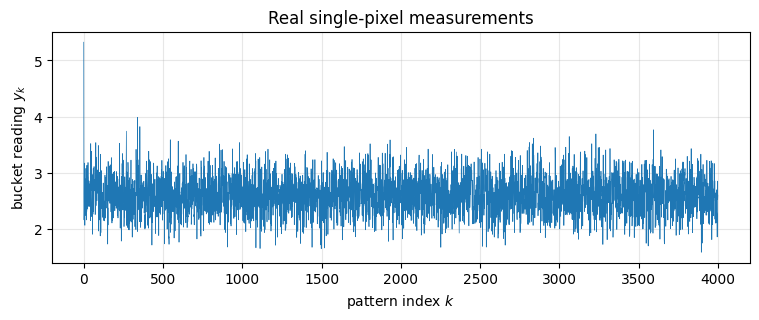

In [3]:
y = load_measurements(r'means\patterns76.txt')
N = y.size
print(f'measurements: N = {N}')
print(f'              mean = {y.mean():.3f}')
print(f'              std  = {y.std():.3f}   (scene-bearing variance)')
print(f'              range = [{y.min():.3f}, {y.max():.3f}]')

plt.figure(figsize=(9, 3))
plt.plot(y, lw=0.5)
plt.xlabel('pattern index $k$')
plt.ylabel(r'bucket reading $y_k$')
plt.title('Real single-pixel measurements')
plt.grid(alpha=0.3); plt.show()

Note that $\mathrm{std}(y) / \mathrm{mean}(y) \approx 4.5\%$ — that small ratio is the fraction of the signal that actually carries scene-dependent information. Most of $y$ is a DC offset (~half the DMD is always on); only the fluctuations contain spatial information about the scene.

## 3. Regenerate the 2 000 binary DMD patterns

Same seed=42 as the lab notebook, generated in batches (one-shot needs ~15 GB of intermediate float64 storage). Cached to a `.npy` after the first run.

regenerating 2000 patterns  (DMD=1140×912, M=76, seed=42) ...
   done in 2.1s
patterns: shape=(2000, 1140, 912, 1), dtype=uint8, size=2079 MB


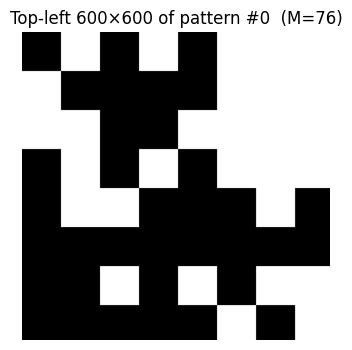

In [ ]:
H, W       = 1140, 912
MACROPIXEL = 76
SEED       = 42
N = 4000

PATTERNS_CACHE = f'patterns_N{N}_M{MACROPIXEL}_seed{SEED}.npy'

if os.path.exists(PATTERNS_CACHE):
    print(f'loading cached patterns from {PATTERNS_CACHE} ...')
    patterns = np.load(PATTERNS_CACHE)
else:
    print(f'regenerating {N} patterns  (DMD={H}×{W}, M={MACROPIXEL}, seed={SEED}) ...')
    t0 = time.time()
    patterns = dmd_random_patterns(W, H,
                                   num_patterns=N,
                                   macropixel=MACROPIXEL,
                                   on_probability=0.5,
                                   )
    print(f'   done in {time.time()-t0:.1f}s')
    np.save(PATTERNS_CACHE, patterns)

print(f'patterns: shape={patterns.shape}, dtype={patterns.dtype}, '
      f'size={patterns.nbytes/1e6:.0f} MB')

preview = min(8 * MACROPIXEL, H, W, 600)
plt.figure(figsize=(4, 4))
plt.imshow(patterns[0, :preview, :preview], cmap='gray')
plt.title(f'Top-left {preview}×{preview} of pattern #0  (M={MACROPIXEL})')
plt.axis('off'); plt.show()

## 4. Build the sensing matrix $\Phi$

Each row of $\Phi$ is a flattened, normalised pattern. With 2000 patterns at 1140×912 the float32 matrix is ~8 GB — fits comfortably in 16 GB of RAM and lets numpy use highly optimised BLAS for `Phi @ x` and `Phi.T @ v`.

In [46]:
# ----- build sensing matrix at macropixel resolution -----
M = MACROPIXEL                         # = 76
h_macro = H // M                       # = 15
w_macro = W // M                       # = 12
n_unknowns = h_macro * w_macro         # = 180

print(f'Image grid to reconstruct: {h_macro} × {w_macro}  →  {n_unknowns} unknowns')
print(f'Measurements available   : N = {N}')
print(f'Overdetermination ratio  : N / n_unknowns = {N / n_unknowns:.1f}×')

# Each M×M block is uniform; one sample per block is enough.
# `patterns` shape is (N, H, W, 1) or (N, H, W) — handle both.
P = patterns if patterns.ndim == 3 else patterns[..., 0]
Phi = (P[:, ::M, ::M].astype(np.float32) / 255.0).reshape(N, -1)

print(f'\nPhi shape: {Phi.shape}, dtype={Phi.dtype}, size={Phi.nbytes/1e6:.1f} MB')


Image grid to reconstruct: 15 × 12  →  180 unknowns
Measurements available   : N = 2000
Overdetermination ratio  : N / n_unknowns = 11.1×

Phi shape: (2000, 180), dtype=float32, size=1.4 MB


## 5. Standard reconstruction — Tikhonov / damped LSQR

Damped least squares: $\hat{x} = \arg\min \tfrac{1}{2}\|\Phi x - y\|_2^2 + \tfrac{1}{2}\mathrm{damp}^2 \|x\|_2^2 .$

With the dense matrix each LSQR iteration is ~0.5 s; 30 iterations finishes in under a minute.

In [ ]:
TIKH_ITER = 20000
DAMP = 0.1            # much less regularisation -- system is overdetermined now

print(f'Running LSQR ({TIKH_ITER} iterations) ...')
t0 = time.time()
res = lsqr(Phi, y, damp=DAMP, iter_lim=TIKH_ITER, show=False)
x_tik = res[0]
print(f'   done in {time.time()-t0:.2f}s    residual = {res[3]:.4g}')

X_tik = x_tik.reshape(h_macro, w_macro)        # 15 × 12, not 1140 × 912
print(f'   reconstruction shape: {X_tik.shape}')
print(f'   reconstruction range: [{X_tik.min():.4g}, {X_tik.max():.4g}]')

Running LSQR (20000 iterations) ...
   done in 0.00s    residual = 13.24
   reconstruction shape: (15, 12)
   reconstruction range: [-0.01578, 0.05806]


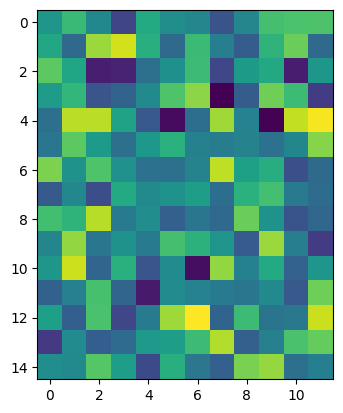

In [21]:
plt.imshow(X_tik)

## 6. NESTA-style reconstruction — TV-regularised FISTA

Adds a total-variation prior that encourages spatial smoothness:
$$\hat{x} = \arg\min \tfrac{1}{2}\|\Phi x - y\|_2^2 + \lambda \, \mathrm{TV}(x).$$

Tune $\lambda$ if the result is too noisy (raise it) or too washed out (lower it).

In [ ]:
NESTA_ITER = 200
LAM = 0.1                # MUCH smaller -- only 180 unknowns to regularise

print(f'Running FISTA+TV ({NESTA_ITER} iterations) ...')
t0 = time.time()
x_tv = reconstruct_nesta_tv(Phi, y.astype(np.float32),
                             image_shape=(h_macro, w_macro),    # 15 × 12
                             lam=LAM, n_iter=NESTA_ITER,
                             tv_inner=10, verbose=False)
print(f'   done in {time.time()-t0:.2f}s')

X_tv = x_tv.reshape(h_macro, w_macro)
print(f'   reconstruction range: [{X_tv.min():.4g}, {X_tv.max():.4g}]')

Running FISTA+TV (200 iterations) ...
   done in 0.10s
   reconstruction range: [-0.01501, 0.05771]


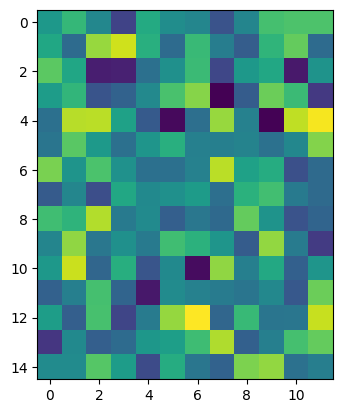

In [23]:
plt.imshow(X_tv)

## 7. Visualise both reconstructions

(912, 1140)


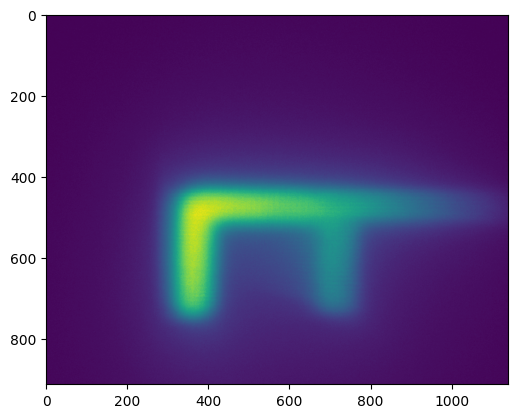

In [31]:
from PIL import Image
import numpy as np

img = Image.open(r'ref_imgs\Image_20260609162224723.bmp').convert("L")
img = img.resize((H, W))
img = np.array(img)

print(img.shape)
plt.imshow(img)

In [ ]:
from spc_cs_l1 import reconstruct_dct_l1, reconstruct_haar_l1

X_dct  = reconstruct_dct_l1 (Phi, y, (h_macro, w_macro),
                             lam_frac=0.01, n_iter=100, nonneg=True, verbose=True)
# X_haar = reconstruct_haar_l1(Phi, y, (h_macro, w_macro),
#                              lam_frac=0.02, n_iter=100, nonneg=True)

# import matplotlib.pyplot as plt
# fig, ax = plt.subplots(1, 3, figsize=(13,4))
# for a,(img,t) in zip(ax, [(X_tik,'Tikhonov'),(X_dct,'DCT + L1'),(X_haar,'Haar + L1')]):
#     a.imshow(img, cmap='gray', interpolation='nearest'); a.set_title(t); a.axis('off')
# plt.tight_layout(); plt.show()

  iter    0  data=98.74  l1=0.06792  obj=98.82
  iter   10  data=97.62  l1=0.1326  obj=97.77
  iter   20  data=96.66  l1=0.2269  obj=96.92
  iter   30  data=95.81  l1=0.3182  obj=96.16
  iter   40  data=95.05  l1=0.4049  obj=95.5
  iter   50  data=94.38  l1=0.4866  obj=94.92
  iter   60  data=93.77  l1=0.5635  obj=94.4
  iter   70  data=93.23  l1=0.636  obj=93.94
  iter   80  data=92.75  l1=0.7043  obj=93.53
  iter   90  data=92.32  l1=0.7687  obj=93.17
  iter   99  data=91.97  l1=0.8235  obj=92.88


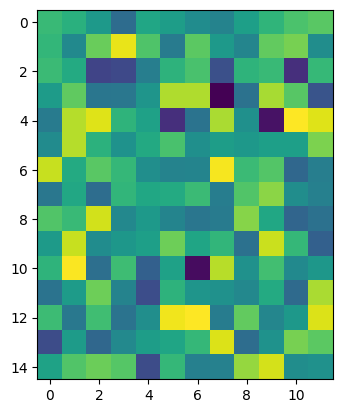

In [25]:
plt.imshow(X_dct)

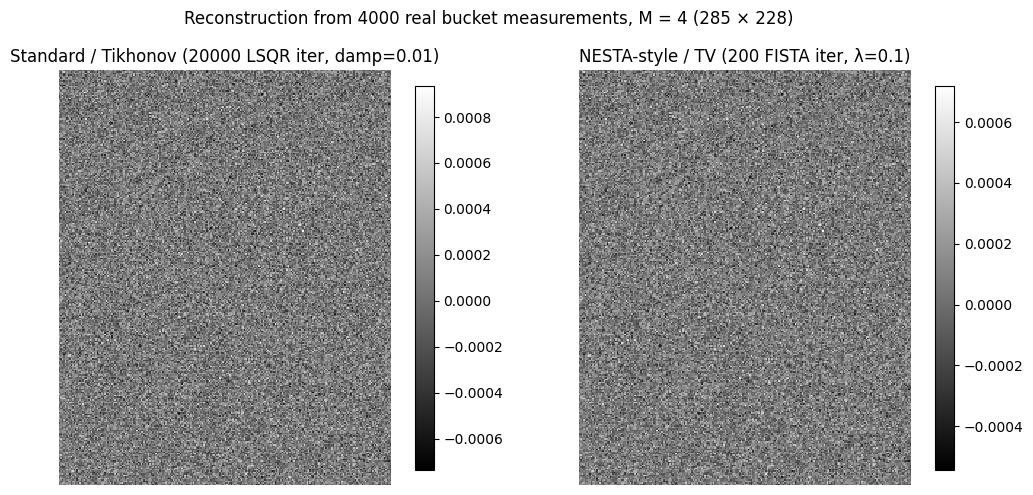

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

im0 = axes[0].imshow(X_tik, cmap='gray', aspect='equal',
                     interpolation='nearest')
axes[0].set_title(f'Standard / Tikhonov ({TIKH_ITER} LSQR iter, damp={DAMP})')
axes[0].axis('off')
plt.colorbar(im0, ax=axes[0], fraction=0.04)

im1 = axes[1].imshow(X_tv, cmap='gray', aspect='equal',
                     interpolation='nearest')
axes[1].set_title(f'NESTA-style / TV ({NESTA_ITER} FISTA iter, λ={LAM})')
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1], fraction=0.04)

plt.suptitle(f'Reconstruction from {N} real bucket measurements, '
             f'M = {MACROPIXEL} ({h_macro} × {w_macro})')
plt.tight_layout(); plt.show()

In [ ]:
import numpy as np
from spc_reference import load_reference, forward_consistency

ref = load_reference(r'ref_imgs\Image_20260609162224723.bmp', (h_macro, w_macro))

print("shapes:  Phi", Phi.shape, " y", np.asarray(y).shape, " ref", ref.size)
print("grid:    h_macro, w_macro =", h_macro, w_macro, " -> N =", h_macro*w_macro)
print("ref range:", ref.min(), ref.max(), " mean", ref.mean())
print("y  range:", np.min(y), np.max(y), " mean", np.mean(y))

forward_consistency(Phi, y, ref)

shapes:  Phi (2000, 180)  y (2616,)  ref 180
grid:    h_macro, w_macro = 15 12  -> N = 180
ref range: 0.00392156862745098 0.29411764705882354  mean 0.04629629629629629
y  range: 0.0848905432440751 16.57408625730994  mean 2.037859619076512
forward-consistency  Phi*ref  vs  y
  correlation(Phi ref, y) = -0.023   (toward +1 = ref explains y)
  fitted scale a = -0.01169,  offset b = 2.013
  relative residual       = 1.000   (toward 0 = good match)
  verdict: WEAK: reference does not explain the data -> check Phi (patterns/M/N/seed) or signal


{'corr': np.float64(-0.022835141171468218),
 'scale': np.float64(-0.011691565331166371),
 'offset': np.float64(2.012975806655068),
 'rel_res': np.float64(0.9997392441669563)}

forward-consistency  Phi*ref  vs  y
  correlation(Phi ref, y) = -0.009   (toward +1 = ref explains y)
  fitted scale a = -0.005942,  offset b = 2.636
  relative residual       = 1.000   (toward 0 = good match)
  verdict: WEAK: reference does not explain the data -> check Phi (patterns/M/N/seed) or signal


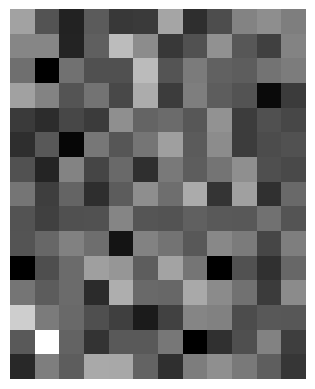

In [36]:
from spc_reference import load_reference, forward_consistency, reconstruct_ref_l1

# load ref ONTO THE RECONSTRUCTION GRID (not the DMD grid), axis order fixed:
ref = load_reference(r'ref_imgs\Image_20260609162224723.bmp', (h_macro, w_macro))

# 1) HONEST CHECK FIRST — does the reference explain your measurements?
forward_consistency(Phi, y, ref)

# 2) what you asked for: data term + 0.01 * ||x - ref||_1
X_ref = reconstruct_ref_l1(Phi, y, (h_macro, w_macro), ref,
                           mu=1, n_iter=6000, nonneg=True)

import matplotlib.pyplot as plt
plt.imshow(X_ref, cmap='gray', interpolation='nearest'); plt.axis('off'); plt.show()

## 8. What we can and cannot conclude from this

### What the math says
* $\Phi$ has 2 000 rows but ~10⁶ columns, so it has a null space of dimension > 10⁶ − 2000. Any reconstruction is the *minimum-norm* (Tikhonov) or *minimum-TV* (NESTA) element of an infinite family that fits the measurements equally well.
* The scene-bearing variance of $y$ (the std around the DC level) is only ~4.5% of the mean; the rest is the DC contribution that does not depend on $X$. This further limits how much information about $X$ is in $\mathbf{y}$.

### Interpreting the figure
* The Tikhonov reconstruction is the minimum-norm element fitting $\mathbf{y}$; it looks noisy because the null space is huge and only a 2000-dim subspace is determined by the data.
* The NESTA-TV reconstruction is constrained to be piecewise-smooth; whatever signal survives projection through $\Phi^\top$ shows up as a smoothed pattern. Large-scale features (e.g. a bright region in one quadrant) would be visible if the lab scene had them.

### What to do next
For M = 1 to yield a recognisable image, one of the following must change:
1. **More measurements** — for a 1140 × 912 reconstruction, on the order of $10^4$–$10^5$ measurements would be needed even with a TV prior.
2. **Acquire at larger macropixel sizes physically** — the next-step experiments at $M \in \{2, 3, 4\}$ will tile small binary patterns across the DMD, drastically reducing the number of unknowns and bringing the problem into the well-determined regime.
3. **A much higher contrast scene** — the small relative std in $y$ suggests low scene contrast; a high-contrast object (printed black shape on white background, USAF target) would give much larger variations.

When the M = 2, 3, 4 datasets are acquired, this notebook extends naturally — same `Phi = patterns.reshape(N, -1) / 255.0` line builds a much smaller matrix, same solvers, much faster runtimes.